In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm
from src.models import srvit

if torch.cuda.is_available():
    dev = "cuda:0"
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
    
elif torch.backends.mps.is_available():
    dev = torch.device("mps")
    torch.set_default_device(dev)
    print(f"Using device: {dev}")
  
else:
    dev = "cpu"
    print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttri

Using device: cuda:0


In [2]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

with open(f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt", "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

In [3]:
n_features = 1
fm, Y_init_f, new_H = rsfm.create_fm("DOFA", Y_init, n_features=n_features, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features = rsfm.get_dofa_features(fm, Y_init_f, wavelengths)
D = int(features.shape[0]/1)

print(f"features: {features.shape}")

alpha = int(features.shape[1]**0.5)
unmixer = rsfm.Unmixing_from_features(D=D, alpha=alpha, B=B, c=c, n_features=n_features, use_cls=False)

features: torch.Size([768, 196])


{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build 

RuntimeError: The size of tensor a (94249) must match the size of tensor b (50176) at non-singleton dimension 0

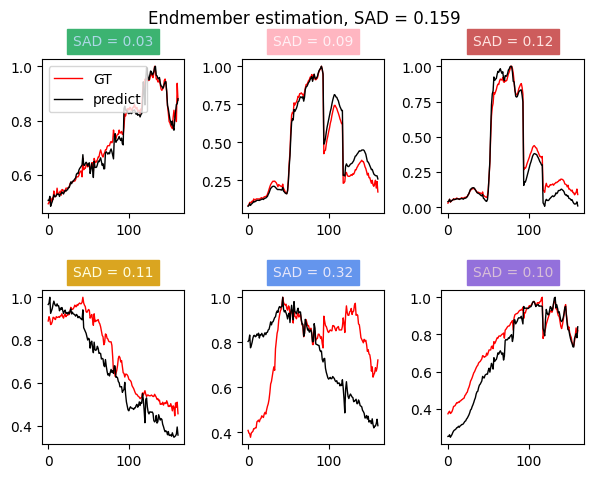

In [ ]:
loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 15
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for n in range(n_xp):

    model = rsfm.Unmixing_from_features(D=D, alpha=alpha, H=new_H, B=B, c=c, n_features=n_features, use_cls=False, is_cnnaeu=False)
    compiled_model = torch.compile(model)
    compiled_model.apply(model.weights_init)
    compiled_model = models.init_decoder_weights(compiled_model, Y_init/Y_init.max(), c, is_unmixer=True, normalize=False)

    compiled_model = compiled_model.to(dev)
    optimizer = build_optim_wrapper(compiled_model, optim_wrapper)

    for epoch in range(epochs):
        
        for Y, E, A in loader:
            optimizer.zero_grad()

            Y = utils.oneD_to_2d(Y).to(dev)
            A = utils.oneD_to_2d(A).to(dev)
            E = E.to(dev)
        
            optimizer.zero_grad()
            
            Y, features = rsfm.extract_f(fm, Y, new_H, wavelengths, use_cls=False)
            E_hat, A_hat, Y_hat = compiled_model(features)
            W_ab, W_mse, W_tv_e, W_tv_a, W_e = 0.6, 0.09, 3e-5, 0, 0
            loss, loss_sad, loss_ab, loss_tv_e, loss_tv_a, loss_mse, loss_norm_e = compiled_model.loss(Y, Y_hat, A_hat, E_hat, 1, W_ab, W_tv_e, W_tv_a, W_mse, W_e)
            
            loss.backward()
            nn.utils.clip_grad_norm_(compiled_model.parameters(), max_norm=10, norm_type=1)
            optimizer.step()

            if hasattr(compiled_model, 'decoder'):
                with torch.no_grad():
                    constraints = models.weightConstraint()
                    compiled_model.decoder.apply(constraints)
            
            # del E_hat, A_hat, Y_hat, features1
        
    compiled_model.eval()

    with torch.no_grad():
        _,A_init, features = rsfm.extract_f(fm, Y, new_H, wavelengths, A,use_cls=False)
        E_hat, A_hat, _ = compiled_model(features)

    E_hats[n] = E_hat
    A_hats[n] = A_hat.squeeze(0)

E_hat_m = torch.mean(E_hats, dim=0)
A_hat_m = torch.mean(A_hats, dim=0)
sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m, A_hat_m, A_init, E, normalize_E=True, normalize_A=True, return_results=True)
print(f"Average SAD = {format(sad, '.3f')}, SAD_A = {format(sad_a, '.3f')}, MSE = {format(mse, '.3f')}")